# Set up

probeA = AM, probeB = PM, probeC = V1, probeD = LM, probeE = AL, probeF = RL

In [1]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [307]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
sns.set_theme()

In [3]:
import pickle
with open('membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [5]:
# Load LFP data
start_time = 0.0
end_time = 0.50
padding = 0.1
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeC','probeD','probeE'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

D:\Anaconda3\lib\site-packages\allensdk\brain_observatory\comparison_utils.py:9: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  from pandas.util.testing import assert_frame_equal


Download time: 1200


D:\Anaconda3\lib\site-packages\allensdk\brain_observatory\ecephys\stimulus_table\naming_utilities.py:146: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
D:\Anaconda3\lib\site-packages\allensdk\brain_observatory\ecephys\ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


# Test kernel smoothing of instantaneous speed

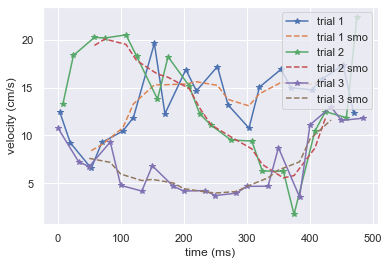

In [23]:
all_time = V1._session.running_speed['mean_time']
all_v = V1._session.running_speed['velocity']
time_list = [1586.1, 1592.1, 1622.1]
for time in time_list:
    idx = (all_time<time+0.5) & (all_time>time)
    plt.plot((all_time[idx]-time)*1000,all_v[idx] , '-*')
    temp = all_v[idx]
    hrly = pd.Series(temp)
    smooth = hrly.rolling(window=5, win_type='gaussian', center=True).mean(std=1)
    plt.plot((all_time[idx]-time)*1000, smooth , '--')
plt.xlabel('time (ms)')
plt.ylabel('velocity (cm/s)')
plt.legend(('trial 1', 'trial 1 smo', 'trial 2', 'trial 2 smo', 'trial 3', 'trial 3 smo',))

# Unit test on 'PP_GLM' class and 'plot_GLM_compare' function

In [88]:
results_list = []

select_trials = V1.running_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=15)
model.add_effect('coupling', 'probeD', peaks_max=150, num=5, nonlinear=0.2 )
model.add_effect('coupling', 'probeE', peaks_max=150, num=5, nonlinear=0.2 )
model.add_effect('twoway_coupling', V1.speed[:,select_trials], peaks_max=100, num=3, nonlinear=0.4)
results_list.append(model.fit('probeC'))

select_trials = V1.stationary_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=15)
model.add_effect('coupling', 'probeD', peaks_max=150, num=5, nonlinear=0.2 )
model.add_effect('coupling', 'probeE', peaks_max=150, num=5, nonlinear=0.2 )
model.add_effect('twoway_coupling', V1.speed[:,select_trials], peaks_max=100, num=3, nonlinear=0.4)
results_list.append(model.fit('probeC'))

label_list = ['running', 'stationary']

Assuming raw inputs are spike trains from probeD
Assuming raw inputs are spike trains from probeE
Assuming raw inputs are spike trains from probeC
Negative log likelihood is: 30525.20
Assuming raw inputs are spike trains from probeD
Assuming raw inputs are spike trains from probeE
Assuming raw inputs are spike trains from probeC
Negative log likelihood is: 49866.02


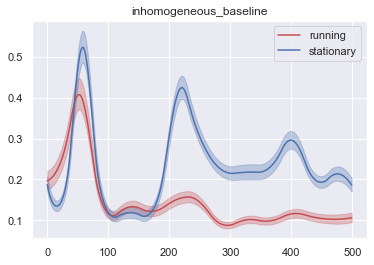

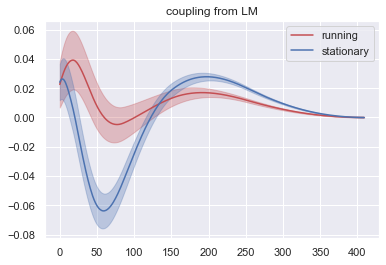

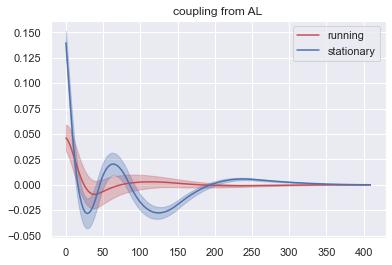

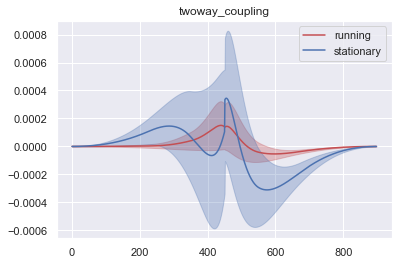

In [85]:
GLM.plot_GLM_compare(model, results_list=results_list, label_list=label_list)

# Model the effect of speed in running trials in different ways

## Load a wider range of speed

In [201]:
# Just to get a wider range of speed
start_time = -0.5
end_time = 1.0
padding = 0.1
V1_wider = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeC','probeD','probeE'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

V1_wider.get_running(method="mine")

Download time: 1200


D:\Anaconda3\lib\site-packages\allensdk\brain_observatory\ecephys\stimulus_table\naming_utilities.py:146: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)


In [202]:
V1_wider.speed.shape

(1500, 210)

## Without speed

Negative log likelihood is: 27805.84
aic/2 is: 27846.84


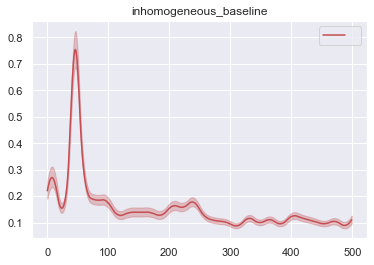

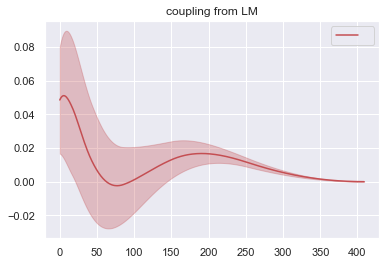

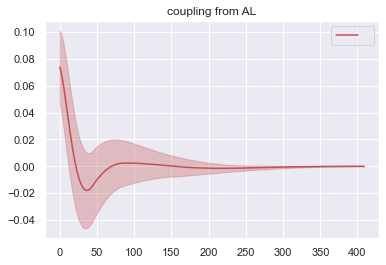

In [594]:
best_time_diff = 150
smooth_std = 20
num_basis_baseline = 30

select_trials = V1.running_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
model.add_effect('coupling', 'probeD', peaks_max=150, num=5, nonlinear=0.2 )
model.add_effect('coupling', 'probeE', peaks_max=150, num=5, nonlinear=0.2 )
model.fit('probeC', verbose=True)
GLM.plot_GLM_compare(model)

## Two way coupling

Negative log likelihood is: 27689.61
aic/2 is: 27735.61


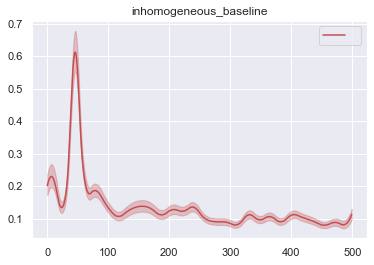

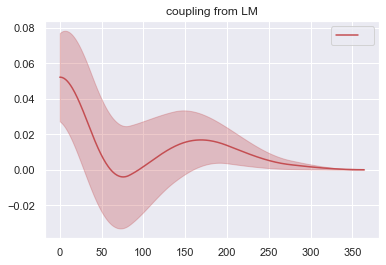

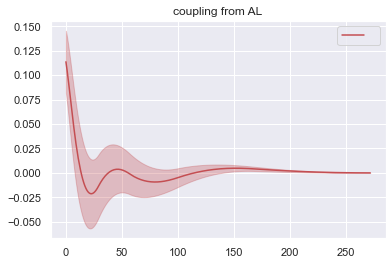

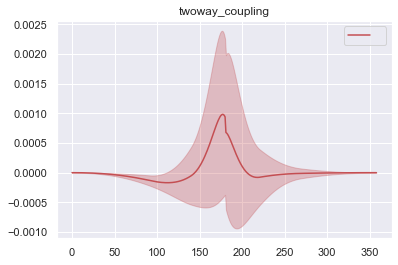

In [621]:
best_time_diff = 150
smooth_std = 20
num_basis_baseline = 30

select_trials = V1.running_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
model.add_effect('coupling', 'probeD', peaks_max=200, num=5, nonlinear=1, verbose=False)
model.add_effect('coupling', 'probeE', peaks_max=100, num=5, nonlinear=0.2)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
model.add_effect('twoway_coupling', smo, peaks_max=40, num=3, nonlinear=0.4)
model.fit('probeC', verbose=True)
GLM.plot_GLM_compare(model)

## Linear term (stationary coefficient)

Negative log likelihood is: 27716.40
aic/2 is: 27758.40


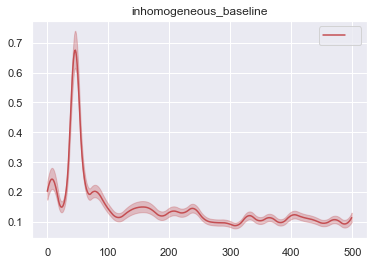

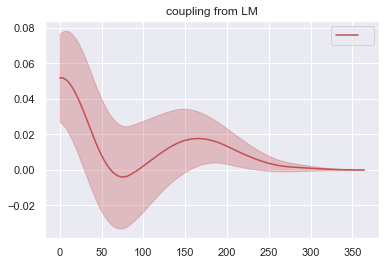

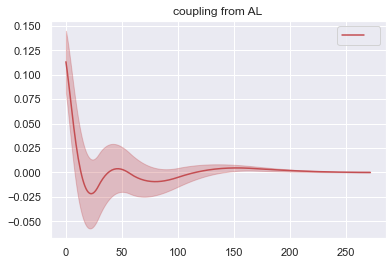

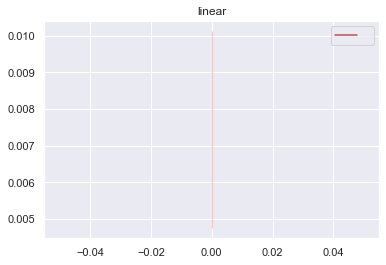

In [633]:
best_time_diff = 350
smooth_std = 20
num_basis_baseline = 30

select_trials = V1.running_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
model.add_effect('coupling', 'probeD', peaks_max=200, num=5, nonlinear=1, verbose=False)
model.add_effect('coupling', 'probeE', peaks_max=100, num=5, nonlinear=0.2)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
model.add_effect('linear', smo)
model.fit('probeC', verbose=True)
GLM.plot_GLM_compare(model)

## Non-stationary coefficient of speed (a function of time)
see next section for details

Negative log likelihood is: 27695.93
aic/2 is: 27747.93


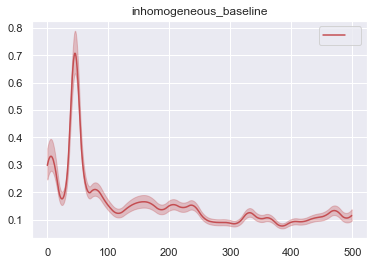

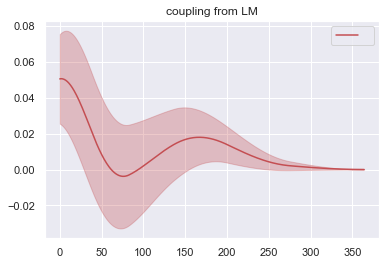

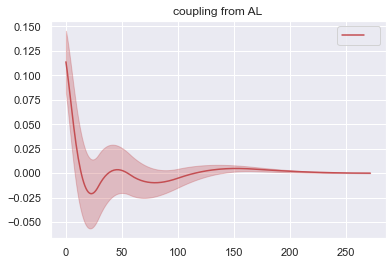

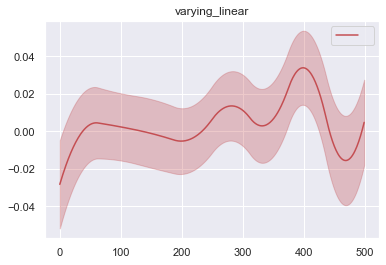

In [598]:
best_time_diff = 150
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 10

select_trials = V1.running_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
model.add_effect('coupling', 'probeD', peaks_max=200, num=5, nonlinear=1, verbose=False)
model.add_effect('coupling', 'probeE', peaks_max=100, num=5, nonlinear=0.2)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
model.add_effect('varying_linear', smo, num=num_varying_linear)
model.fit('probeC', verbose=True)
GLM.plot_GLM_compare(model)

Therefore, time varying linear coefficient seems to fit best. 

# Hyperparameter tunning of non-stationary coefficient

## Number of basis for baseline

In [569]:
##### Cell for CV
n_cv = 10
para_list = np.arange(5,60,2)
all_considered_trial_idx = np.where(V1.running_trial_index)[0]

##### Other parameters
best_time_diff = 0
smooth_std = 1
num_basis_baseline = 30
num_varying_linear = 10

##### 
nlogli_rcd = np.zeros((len(para_list), n_cv))
template_for_kf = np.zeros((len(all_considered_trial_idx),1))

from sklearn.model_selection import KFold
kf = KFold(n_splits=n_cv)
kf.get_n_splits(template_for_kf)

for i, num_basis_baseline in enumerate(tqdm(para_list)):
    j = 0
    for train_index, test_index in kf.split(template_for_kf):
        select_trials = np.full(V1.ntrial, False)
        select_trials[all_considered_trial_idx[train_index]] = True
        test_trials = np.full(V1.ntrial, False)
        test_trials[all_considered_trial_idx[test_index]] = True

        model = GLM.PP_GLM(dataset=V1, 
                           select_trials=select_trials, 
                           membership=membership, 
                           condition_ids=condition_ids)
        model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
        model.add_effect('coupling', 'probeD', peaks_max=250, num=5, nonlinear=0.2 )
        model.add_effect('coupling', 'probeE', peaks_max=150, num=5, nonlinear=0.2 )
        smo = utils.kernel_smoothing(V1_wider.speed, 
                                     smooth_std)[(500+best_time_diff):(1000+best_time_diff),:]
        model.add_effect('varying_linear', smo, num=num_varying_linear)
        model.fit('probeC', verbose=False)

        nlogli_rcd[i, j] = model.test(test_trials)
        j += 1

100%|███████████████████████████████████████████████████████████████████| 28/28 [10:47<00:00, 23.12s/it]


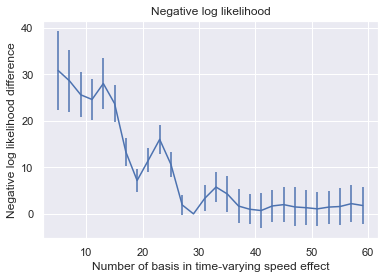

In [570]:
best_id = np.argmin(nlogli_rcd.mean(axis=1))
x = para_list
y = (nlogli_rcd-nlogli_rcd[best_id,:]).mean(axis=1)
dy = 2*(nlogli_rcd-nlogli_rcd[best_id,:]).std(axis=1)/np.sqrt(nlogli_rcd.shape[1])

plt.figure()
plt.errorbar(x, y, yerr=dy)
plt.title(f"Negative log likelihood")
plt.xlabel(f"Number of basis in time-varying speed effect")
plt.ylabel(f"Negative log likelihood difference")
plt.show()

Best is round 30

## Discover lead or lag

In [571]:
##### Cell for CV
n_cv = 10
para_list = np.arange(-400, 401, 20)
all_considered_trial_idx = np.where(V1.running_trial_index)[0]

##### Other parameters
best_time_diff = 0
smooth_std = 1
num_basis_baseline = 30
num_varying_linear = 10

##### 
nlogli_rcd = np.zeros((len(para_list), n_cv))
template_for_kf = np.zeros((len(all_considered_trial_idx),1))

from sklearn.model_selection import KFold
kf = KFold(n_splits=n_cv)
kf.get_n_splits(template_for_kf)

for i, best_time_diff in enumerate(tqdm(para_list)):
    j = 0
    for train_index, test_index in kf.split(template_for_kf):
        select_trials = np.full(V1.ntrial, False)
        select_trials[all_considered_trial_idx[train_index]] = True
        test_trials = np.full(V1.ntrial, False)
        test_trials[all_considered_trial_idx[test_index]] = True

        model = GLM.PP_GLM(dataset=V1, 
                           select_trials=select_trials, 
                           membership=membership, 
                           condition_ids=condition_ids)
        model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
        model.add_effect('coupling', 'probeD', peaks_max=250, num=5, nonlinear=0.2 )
        model.add_effect('coupling', 'probeE', peaks_max=150, num=5, nonlinear=0.2 )
        smo = utils.kernel_smoothing(V1_wider.speed, 
                                     smooth_std)[(500+best_time_diff):(1000+best_time_diff),:]
        model.add_effect('varying_linear', smo, num=num_varying_linear)
        model.fit('probeC', verbose=False)

        nlogli_rcd[i, j] = model.test(test_trials)
        j += 1

100%|███████████████████████████████████████████████████████████████████| 41/41 [23:25<00:00, 34.28s/it]


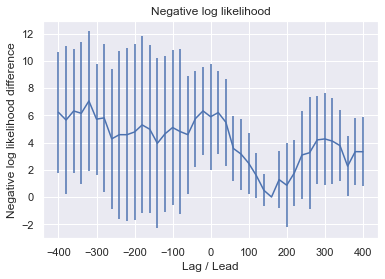

In [575]:
best_id = np.argmin(nlogli_rcd.mean(axis=1))
x = para_list
y = (nlogli_rcd-nlogli_rcd[best_id,:]).mean(axis=1)
dy = 2*(nlogli_rcd-nlogli_rcd[best_id,:]).std(axis=1)/np.sqrt(nlogli_rcd.shape[1])

plt.figure()
plt.errorbar(x, y, yerr=dy)
plt.title(f"Negative log likelihood")
plt.xlabel(f"Lag / Lead")
plt.ylabel(f"Negative log likelihood difference")
plt.show()

 Best time diff = 150

## Discover smoothing

In [576]:
##### Cell for CV
n_cv = 10
para_list = np.logspace(0, 2.3, 10)
all_considered_trial_idx = np.where(V1.running_trial_index)[0]

##### Other parameters
best_time_diff = 150
smooth_std = 1
num_basis_baseline = 30
num_varying_linear = 10

##### 
nlogli_rcd = np.zeros((len(para_list), n_cv))
template_for_kf = np.zeros((len(all_considered_trial_idx),1))

from sklearn.model_selection import KFold
kf = KFold(n_splits=n_cv)
kf.get_n_splits(template_for_kf)

for i, smooth_std in enumerate(tqdm(para_list)):
    j = 0
    for train_index, test_index in kf.split(template_for_kf):
        select_trials = np.full(V1.ntrial, False)
        select_trials[all_considered_trial_idx[train_index]] = True
        test_trials = np.full(V1.ntrial, False)
        test_trials[all_considered_trial_idx[test_index]] = True

        model = GLM.PP_GLM(dataset=V1, 
                           select_trials=select_trials, 
                           membership=membership, 
                           condition_ids=condition_ids)
        model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
        model.add_effect('coupling', 'probeD', peaks_max=250, num=5, nonlinear=0.2 )
        model.add_effect('coupling', 'probeE', peaks_max=150, num=5, nonlinear=0.2 )
        smo = utils.kernel_smoothing(V1_wider.speed, 
                                     smooth_std)[(500+best_time_diff):(1000+best_time_diff),:]
        model.add_effect('varying_linear', smo, num=num_varying_linear)
        model.fit('probeC', verbose=False)

        nlogli_rcd[i, j] = model.test(test_trials)
        j += 1

100%|███████████████████████████████████████████████████████████████████| 10/10 [06:13<00:00, 37.39s/it]


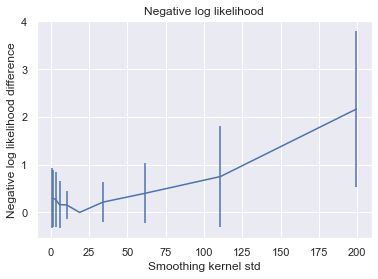

In [577]:
best_id = np.argmin(nlogli_rcd.mean(axis=1))
x = para_list
y = (nlogli_rcd-nlogli_rcd[best_id,:]).mean(axis=1)
dy = 2*(nlogli_rcd-nlogli_rcd[best_id,:]).std(axis=1)/np.sqrt(nlogli_rcd.shape[1])

plt.figure()
plt.errorbar(x, y, yerr=dy)
plt.title(f"Negative log likelihood")
plt.xlabel(f"Smoothing kernel std")
plt.ylabel(f"Negative log likelihood difference")
plt.show()

Best smoothing kernel std is 20

## Number of basis for time-varying coefficient of speed

In [578]:
##### Cell for CV
n_cv = 10
para_list = np.arange(4,30,2)
all_considered_trial_idx = np.where(V1.running_trial_index)[0]

##### Other parameters
best_time_diff = 150
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 10

##### 
nlogli_rcd = np.zeros((len(para_list), n_cv))
template_for_kf = np.zeros((len(all_considered_trial_idx),1))

from sklearn.model_selection import KFold
kf = KFold(n_splits=n_cv)
kf.get_n_splits(template_for_kf)

for i, num_varying_linear in enumerate(tqdm(para_list)):
    j = 0
    for train_index, test_index in kf.split(template_for_kf):
        select_trials = np.full(V1.ntrial, False)
        select_trials[all_considered_trial_idx[train_index]] = True
        test_trials = np.full(V1.ntrial, False)
        test_trials[all_considered_trial_idx[test_index]] = True

        model = GLM.PP_GLM(dataset=V1, 
                           select_trials=select_trials, 
                           membership=membership, 
                           condition_ids=condition_ids)
        model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
        model.add_effect('coupling', 'probeD', peaks_max=250, num=5, nonlinear=0.2 )
        model.add_effect('coupling', 'probeE', peaks_max=150, num=5, nonlinear=0.2 )
        smo = utils.kernel_smoothing(V1_wider.speed, 
                                     smooth_std)[(500+best_time_diff):(1000+best_time_diff),:]
        model.add_effect('varying_linear', smo, num=num_varying_linear)
        model.fit('probeC', verbose=False)

        nlogli_rcd[i, j] = model.test(test_trials)
        j += 1

100%|███████████████████████████████████████████████████████████████████| 13/13 [09:02<00:00, 41.71s/it]


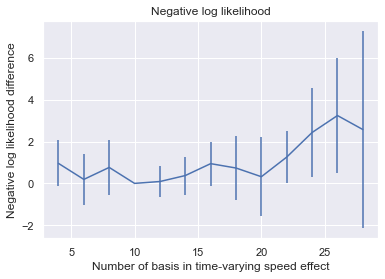

In [579]:
best_id = np.argmin(nlogli_rcd.mean(axis=1))
x = para_list
y = (nlogli_rcd-nlogli_rcd[best_id,:]).mean(axis=1)
dy = 2*(nlogli_rcd-nlogli_rcd[best_id,:]).std(axis=1)/np.sqrt(nlogli_rcd.shape[1])

plt.figure()
plt.errorbar(x, y, yerr=dy)
plt.title(f"Negative log likelihood")
plt.xlabel(f"Number of basis in time-varying speed effect")
plt.ylabel(f"Negative log likelihood difference")
plt.show()

## Plot best model

Negative log likelihood is: 27695.93
aic/2 is: 27747.93


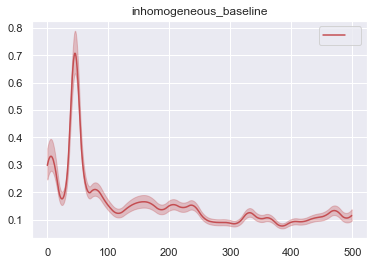

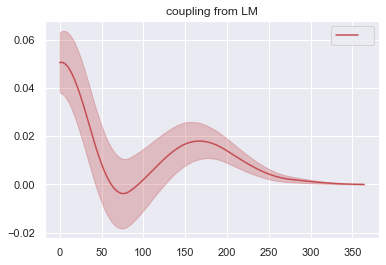

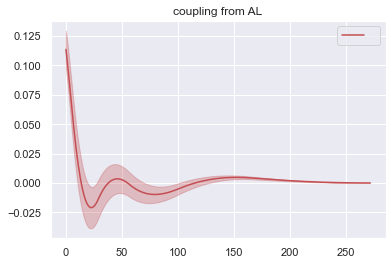

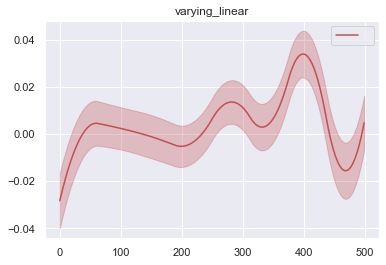

In [583]:
best_time_diff = 150
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 10

select_trials = V1.running_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
model.add_effect('coupling', 'probeD', peaks_max=200, num=5, nonlinear=1, verbose=False)
model.add_effect('coupling', 'probeE', peaks_max=100, num=5, nonlinear=0.2)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
model.add_effect('varying_linear', smo, num=num_varying_linear)
model.fit('probeC', verbose=True)
GLM.plot_GLM_compare(model)